In [18]:
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from data import alt_dataset
from models.lenet import lenet
from models.lenetAlt import LeNetAlt
from tools.meter import AverageMeter

In [19]:
# experiments = [os.path.join(".", "training/experiment2"), os.path.join(".", "training/experiment3")]
experiments = [os.path.join(".", "training/experiment_lenetAlt_1_cifar10")]
dataset = "cifar10"
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


In [20]:
if dataset == "mnist":
    hidden = 588
    channel = 1
    inputSize = (28, 28)
    classes = 10
elif dataset == "cifar10":
    hidden = 768
    channel = 3
    inputSize = (32, 32)
    classes = 10

# model = lenet(hidden=hidden, channel=channel)
model = LeNetAlt(num_classes=classes, channels=channel, input_size=inputSize)

In [21]:
def evaluateModel(checkPointPath, loaders): # (test acc, train acc)
    checkpoint = torch.load(checkPointPath, map_location=device)
    model.load_state_dict(checkpoint["state_dicts"]["network"])
    model.to(device)

    model.eval()
    testAcc = AverageMeter()
    trainAcc = AverageMeter()
    for x, y in loaders["test"]:
        x, y = x.to(device), y.to(device)
        with torch.no_grad():
            fx = model(x)
        testAcc.update(torch.argmax(fx, 1).eq(y).float().mean(), y.size(0))

    for x, y in loaders["train"]:
        x, y = x.to(device), y.to(device)
        with torch.no_grad():
            fx = model(x)
        trainAcc.update(torch.argmax(fx, 1).eq(y).float().mean(), y.size(0))
    
    return testAcc.avg, trainAcc.avg
        

In [22]:
results = pd.DataFrame(columns=[
    "batch_size",
    "lr",
    "alpha",
    "mu",
    "p",
    "checkpoint_type",
    "test_acc",
    "train_acc"
])

In [23]:
folders = []
for modelPaths in experiments:
    folders.extend(os.listdir(modelPaths))
folders.sort()
for folder in folders:
    if folder == "training" or not os.path.isdir(os.path.join(modelPaths, folder)):
        continue
    
    params = folder.split("_")
    batch_size = params[2]
    lr = params[4]
    alpha = params[6]
    mu = params[8]
    p = params[10]
    print(f"Batch Size: {batch_size}, lr: {lr}, alpha: {float(alpha):.2f}, mu: {mu}, p: {p}")
    print("\tTest\tTrain")

    for checkpointType in ["best.pth", "ckpt.pth"]:
        checkPath = os.path.join(modelPaths, folder, checkpointType)
        if not os.path.isfile(checkPath):
            continue

        loaders, class_num = alt_dataset(dataset,  int(batch_size))
        testAcc, trainAcc = evaluateModel(checkPath, loaders)

        results.loc[len(results)] = [
            int(batch_size),
            float(lr),
            float(alpha),
            float(mu),
            float(p),
            checkpointType.split(".")[0],
            float(testAcc),
            float(trainAcc) 
        ]
        
        print(f"{checkpointType[:-4]}: {100 * testAcc:.2f}%\t{100 * trainAcc:.2f}%")
    print()


Batch Size: 128, lr: 0.1, alpha: 0.50, mu: 1.54e-10, p: 0.0
	Test	Train
best: 10.00%	10.00%
ckpt: 11.00%	10.00%

Batch Size: 128, lr: 0.1, alpha: 0.50, mu: 1e-05, p: 0.0
	Test	Train
best: 36.00%	35.25%
ckpt: 11.00%	10.00%

Batch Size: 128, lr: 0.1, alpha: 0.50, mu: 1e-07, p: 0.0
	Test	Train
best: 5.00%	10.01%
ckpt: 11.00%	10.00%

Batch Size: 128, lr: 0.1, alpha: 0.50, mu: 1e-09, p: 0.0
	Test	Train
best: 4.00%	10.01%
ckpt: 15.00%	9.99%

Batch Size: 128, lr: 0.1, alpha: 0.50, mu: 1e-15, p: 0.0
	Test	Train
best: 57.00%	60.22%
ckpt: 15.00%	9.99%

Batch Size: 128, lr: 0.1, alpha: 0.50, mu: 1e-17, p: 0.0
	Test	Train
best: 4.00%	10.01%
ckpt: 15.00%	9.99%

Batch Size: 128, lr: 0.1, alpha: 0.50, mu: 1e-30, p: 0.0
	Test	Train
best: 54.00%	53.69%
ckpt: 15.00%	9.99%

Batch Size: 128, lr: 0.1, alpha: 0.50, mu: 3.85e-10, p: 0.0
	Test	Train
best: 17.00%	16.26%
ckpt: 11.00%	10.07%

Batch Size: 128, lr: 0.1, alpha: 0.50, mu: 6.92e-10, p: 0.0
	Test	Train
best: 11.00%	10.00%
ckpt: 5.00%	10.01%

Batch Siz

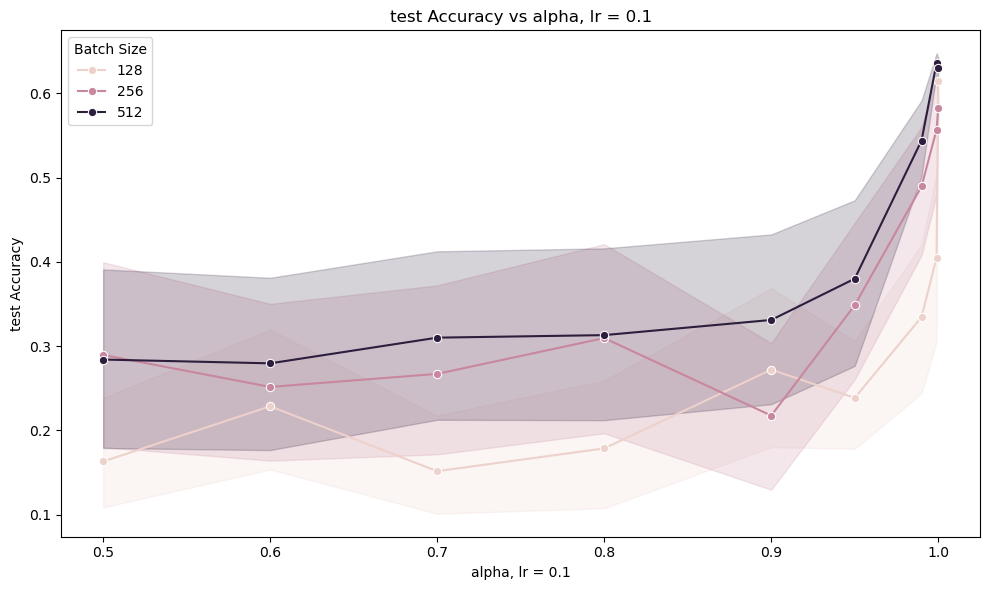

In [24]:
results_lr_01 = results[results["lr"] == 0.1]

trainOrTest = "test"

plt.figure(figsize=(10, 6))
sns.lineplot(
    data = results_lr_01,
    x = "alpha",
    y = f"{trainOrTest}_acc",
    hue = "batch_size",
    marker = "o"
)

plt.title(f"{trainOrTest} Accuracy vs alpha, lr = 0.1")
plt.xlabel("alpha, lr = 0.1")
plt.ylabel(f"{trainOrTest} Accuracy")
plt.legend(title="Batch Size")
plt.tight_layout()

plt.show()

In [27]:
batchSize = 512
ckptType = "best"

filtered = results[
    (results["batch_size"] == batchSize) &
    (results["checkpoint_type"] == ckptType)
].copy()

df = pd.pivot_table(
    filtered,
    values="test_acc",
    index="mu",
    columns="alpha"
)

df = df.sort_index(axis=0, ascending=True)

grandMedian = df.stack().median()

df["alpha median"] = df.median(axis=1)

colMedians = df.median(axis=0)
colMedians.name = "mu median"

df = pd.concat([df, colMedians.to_frame().T])


df.loc["mu median", "alpha median"] = grandMedian

output_filename = f"training_{batchSize}.csv"
df.to_csv(output_filename)